# 🏦 **Customer Churn Modelling Analysis**

## 📖 Introduction
Customer churn refers to when customers stop using a company’s services.  
In the banking industry, predicting churn is vital because retaining existing customers is more cost-effective than acquiring new ones.

This project analyzes a bank’s customer dataset to understand the factors that influence churn and predict which customers are likely to leave.  
Using demographic, financial, and behavioral data, we aim to identify key churn drivers, segment customers, and provide insights to improve customer retention.
ion.n.


## Problem Statement
The bank is experiencing customer attrition and wants to understand why customers are leaving.  
The goal is to identify at-risk customers and the factors contributing to churn so that effective retention strategies can be developed.


## 🎯 Objectives

1. **Identify Key Drivers of Customer Churn**  
   Determine the major demographic, financial, and behavioral factors—such as age, credit score, balance, and activity status—that influence customer attrition.

2. **Analyze Customer Segments**  
   Examine churn trends across different AgeGroups (Young, Middle-Aged, Senior) and RiskLevels (Low, Medium, High) to uncover patterns among various customer segments.

3. **Develop Predictive Models for Churn**  
   Build and evaluate machine learning models to predict the likelihood of customer churn and assess model performance for accuracy and reliability.

4. **Provide Actionable Business Insights**  
   Generate data-driven recommendations to help the company improve customer retention, focusing on high-risk and inactive customer groups.


## 🧾 Data Description

The dataset contains information about 10,000 bank customers and is used to predict customer churn — whether a customer leaves the bank (`Exited = 1`) or stays (`Exited = 0`).

### **Features Overview**

| Column | Description |
|---------|-------------|
| **RowNumber** | Record index (not analytically relevant). |
| **CustomerId** | Unique identifier for each customer. |
| **Surname** | Customer’s last name. |
| **CreditScore** | Numerical score representing the customer’s creditworthiness. |
| **Geography** | Country where the customer resides. |
| **Gender** | Gender of the customer. |
| **Age** | Age of the customer in years. |
| **Tenure** | Number of years the customer has been with the bank. |
| **Balance** | Account balance (converted from float to int). |
| **NumOfProducts** | Number of bank products the customer holds. |
| **HasCrCard** | 1 if the customer has a credit card, otherwise 0. |
| **IsActiveMember** | 1 if the customer is active, otherwise 0. |
| **EstimatedSalary** | Estimated annual salary of the customer. |
| **Exited** | Target variable — 1 if the customer exited, 0 otherwise. |



### Import Libraries & Load Data

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
import warnings
warnings.filterwarnings('ignore')

In [69]:
# Load dataset
df = pd.read_csv('Churn_Modelling.csv')

# Preview dataset
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [70]:
# Basic information
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Information of Dataset
* Columns = 14
* Rows = 10000
* Data types
   * float = 2
   * int64 = 9
   * object = 3

### Data Cleaning & Feature Engineering

#### Checking duplicates

In [71]:
df.duplicated().sum()

0

##### No duplicated values

#### Checking null values

In [72]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

##### No null values

#### Convert datatypes

In [73]:
df['Balance']=df['Balance'].astype(int)

In [74]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

#### Add Columns

In [75]:
df['Age'].min()

18

In [76]:
df['Age'].max()

92

In [77]:
df['AgeGroup']=pd.cut(df['Age'],bins=[df['Age'].min(),30,60,df['Age'].max()],labels=['Young','Middle-Aged','Seniors'])

In [78]:
df['CreditScore'].min()

350

In [79]:
df['CreditScore'].max()

850

In [80]:
df['RiskLevel']=pd.cut(df['CreditScore'],bins=[df['CreditScore'].min(),500,600,df['CreditScore'].max()],labels=['Low','Medium','High']) 

### Exploratory Data Analysis (EDA)

### Objective 1: Identify Key Drivers of Customer Churn

### 1. Churn Distribution

Shows the proportion of customers who stayed vs. exited — helps understand churn imbalance.

In [81]:
corporate_blue = ["#0A3D62", "#3C6382", "#60A3BC", "#82CCDD", "#A4B0BE"]
churn_red = "#E55039"
churn_palette = [corporate_blue[0], churn_red]

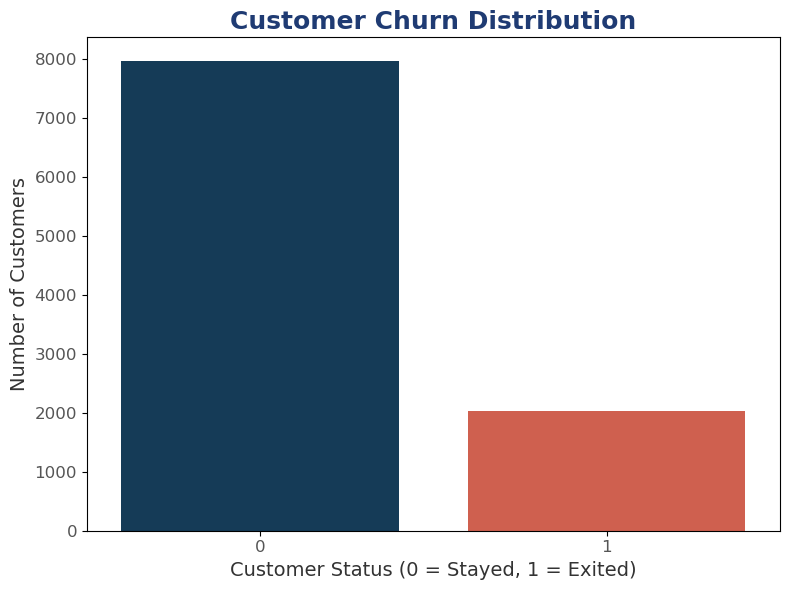

In [82]:
plt.figure(figsize=(8,6))

sns.countplot(x='Exited', data=df, palette=churn_palette)

plt.title("Customer Churn Distribution", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Customer Status (0 = Stayed, 1 = Exited)", fontsize=14, color='#333333')
plt.ylabel("Number of Customers", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
# plt.savefig("Customer_Churn_Distribution.png", dpi=300)
plt.show()


## Interpretation
* The chart shows a **strong imbalance**: most customers **stay (\~8000)**, while a smaller group **churns (\~2000)**.
* This means the churn rate is roughly **20–25%**, which is significant for business impact.
* The imbalance will affect modeling, so techniques like **class weighting or resampling** will be needed.

### 2. Churn Rate by Gender

Helps determine whether gender influences churn likelihood.

In [83]:
# Colors
corporate_blue = ["#0A3D62", "#3C6382"]
churn_red = "#E55039"

gender_palette = [corporate_blue[0], churn_red]

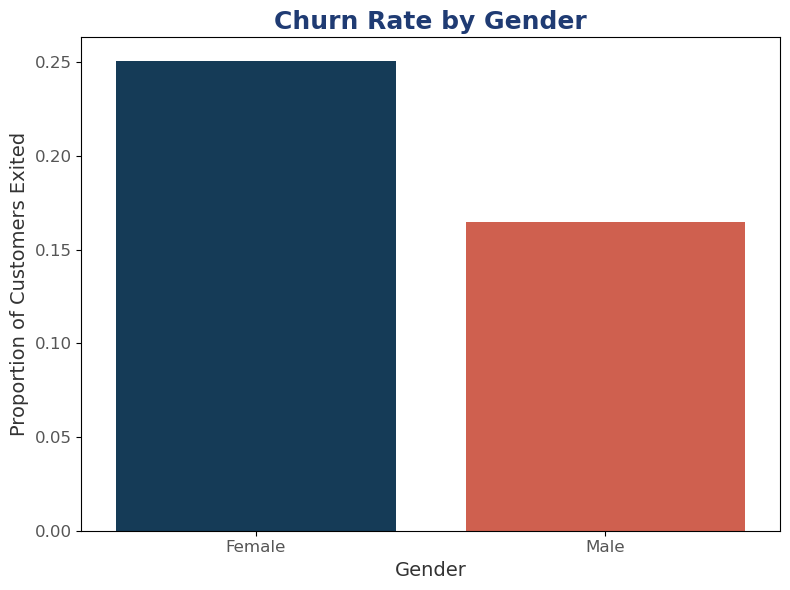

In [84]:
plt.figure(figsize=(8,6))

sns.barplot(x='Gender', y='Exited', data=df, palette=gender_palette, errorbar=None)

plt.title("Churn Rate by Gender", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Gender", fontsize=14, color='#333333')
plt.ylabel("Proportion of Customers Exited", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
# plt.savefig("Churn_Rate_by_Gender.png", dpi=300)
plt.show()

## Interpretation
* **Females show a higher churn rate (\~25%)** compared to
* **Males (\~18%)**.

This suggests **gender does have some influence on churn**, with women leaving at a slightly higher rate.

### 3. Churn Rate by Geography

Analyzes regional impact on churn behavior.

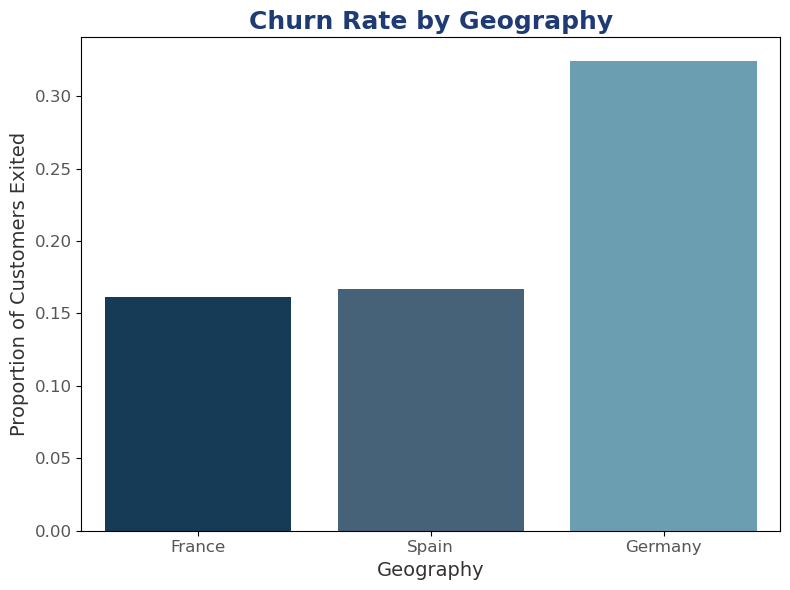

In [85]:
plt.figure(figsize=(8,6))

corporate_geo_palette = ["#0A3D62", "#3C6382", "#60A3BC"]

sns.barplot(x='Geography', y='Exited', data=df, palette=corporate_geo_palette, errorbar=None)

plt.title("Churn Rate by Geography", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Geography", fontsize=14, color='#333333')
plt.ylabel("Proportion of Customers Exited", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
# plt.savefig("Churn_Rate_by_Geography.png", dpi_
plt.show()

## Interpretation
* **Germany has the highest churn rate (\~32%)**, significantly above the other regions.
* **Spain shows a moderate churn rate (\~17%)**.
* **France has the lowest churn rate (\~15%)**.

This indicates that **geography strongly influences churn**, with German customers being far more likely to leave.

### 4. Age vs. Churn

Older customers may show different churn tendencies — visualize using boxplot.

In [86]:
# colors
corporate_blue = "#0A3D62"
churn_red = "#E55039"

box_palette = [corporate_blue, churn_red]

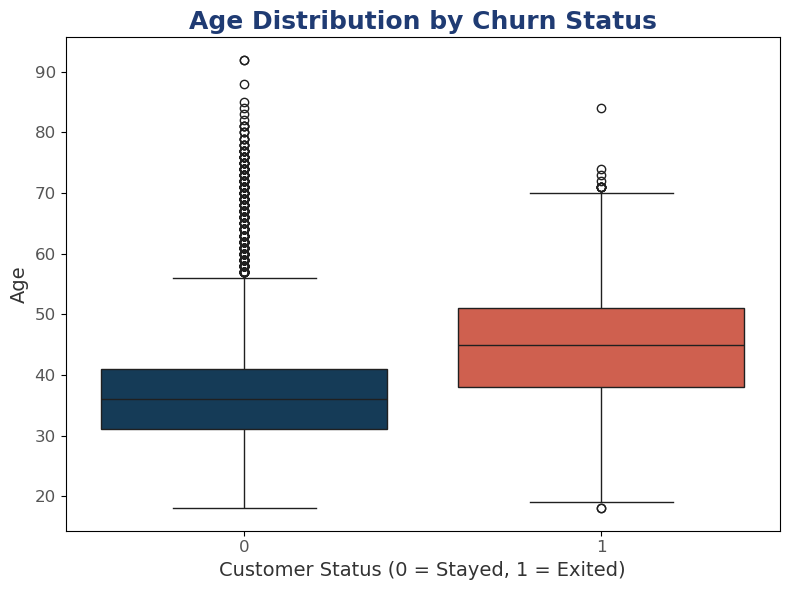

In [87]:
plt.figure(figsize=(8,6))

sns.boxplot(x='Exited', y='Age', data=df, palette=box_palette)

plt.title("Age Distribution by Churn Status", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Customer Status (0 = Stayed, 1 = Exited)", fontsize=14, color='#333333')
plt.ylabel("Age", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
# plt.savefig("Age_vs_Churn_Boxplot.png", dpi=300)
plt.show()

## Interpretation
**Older customers are more likely to churn**.
The boxplot shows that the **median and overall age** of customers who exited is **higher** than those who stayed. Non-churners tend to be younger, while churners are concentrated in older age ranges. Outliers exist in both groups but don’t change the trend.

### 5. Credit Score vs. Churn

Check if low credit score customers churn more often.

In [88]:
corporate_blue = "#0A3D62"
churn_red = "#E55039"

box_palette = [corporate_blue, churn_red]

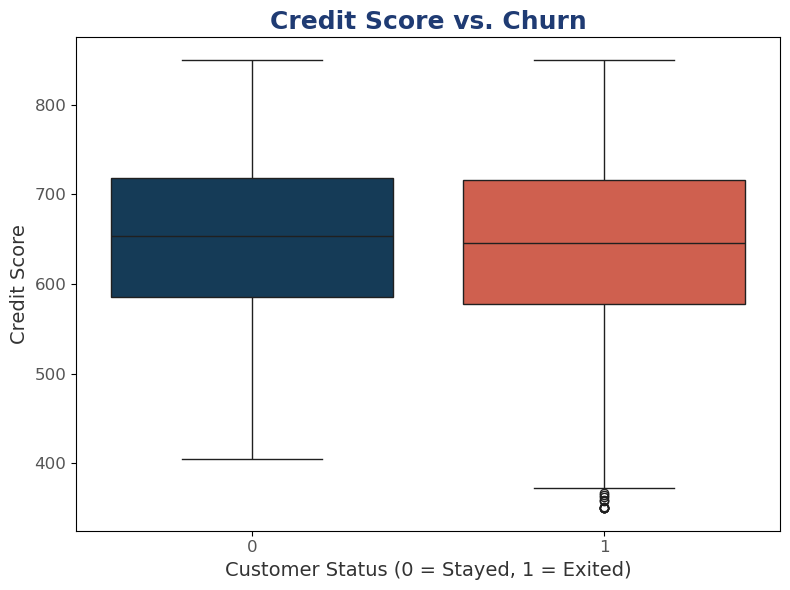

In [89]:
plt.figure(figsize=(8,6))

sns.boxplot(x='Exited', y='CreditScore', data=df, palette=box_palette)

plt.title("Credit Score vs. Churn", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Customer Status (0 = Stayed, 1 = Exited)", fontsize=14, color='#333333')
plt.ylabel("Credit Score", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
# plt.savefig("CreditScore_vs_Churn.png", dpi=300)
plt.show()

## Interpretation
Credit scores look very similar between customers who stayed and those who exited.
There’s **no strong difference** in median score or spread, suggesting that **credit score does not significantly influence churn** in this dataset.

### 6. Balance vs. Churn

Understand whether customers with higher/lower balances are more likely to churn.

In [90]:
corporate_blue = "#0A3D62"
churn_red = "#E55039"

box_palette = [corporate_blue, churn_red]

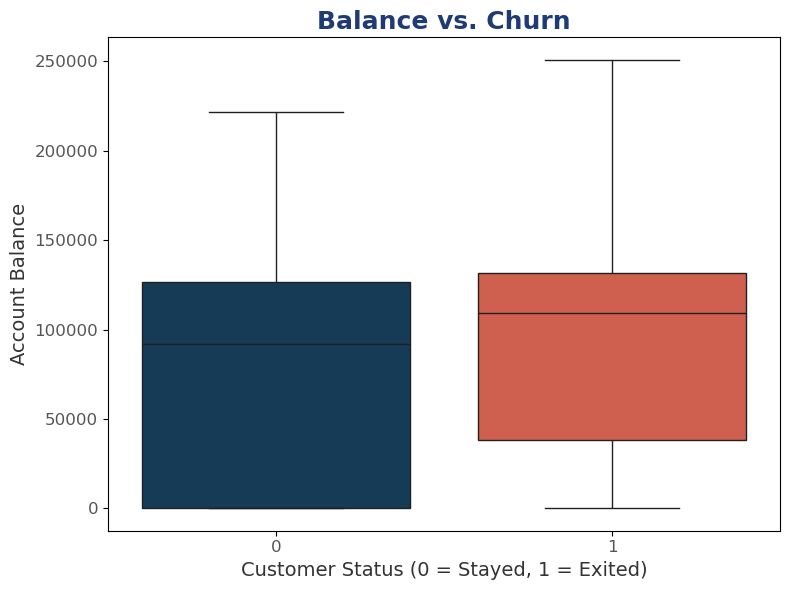

In [91]:
plt.figure(figsize=(8,6))

sns.boxplot(x='Exited', y='Balance', data=df, palette=box_palette)

plt.title("Balance vs. Churn", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Customer Status (0 = Stayed, 1 = Exited)", fontsize=14, color='#333333')
plt.ylabel("Account Balance", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
# plt.savefig("Balance_vs_Churn.png", dpi=300)
plt.show()

## Interpretation
Customers who churn tend to have **higher account balances** than those who remain.
The churn group’s median and overall distribution are shifted upward, suggesting that **higher-balance customers are more likely to exit** in this dataset.

### 7. Activity and Credit Card Status vs. Churn

Compare churn rates based on membership activity and credit card ownership.

In [92]:
corporate_blue = "#0A3D62"
churn_red = "#E55039"
dual_palette = [corporate_blue, churn_red]

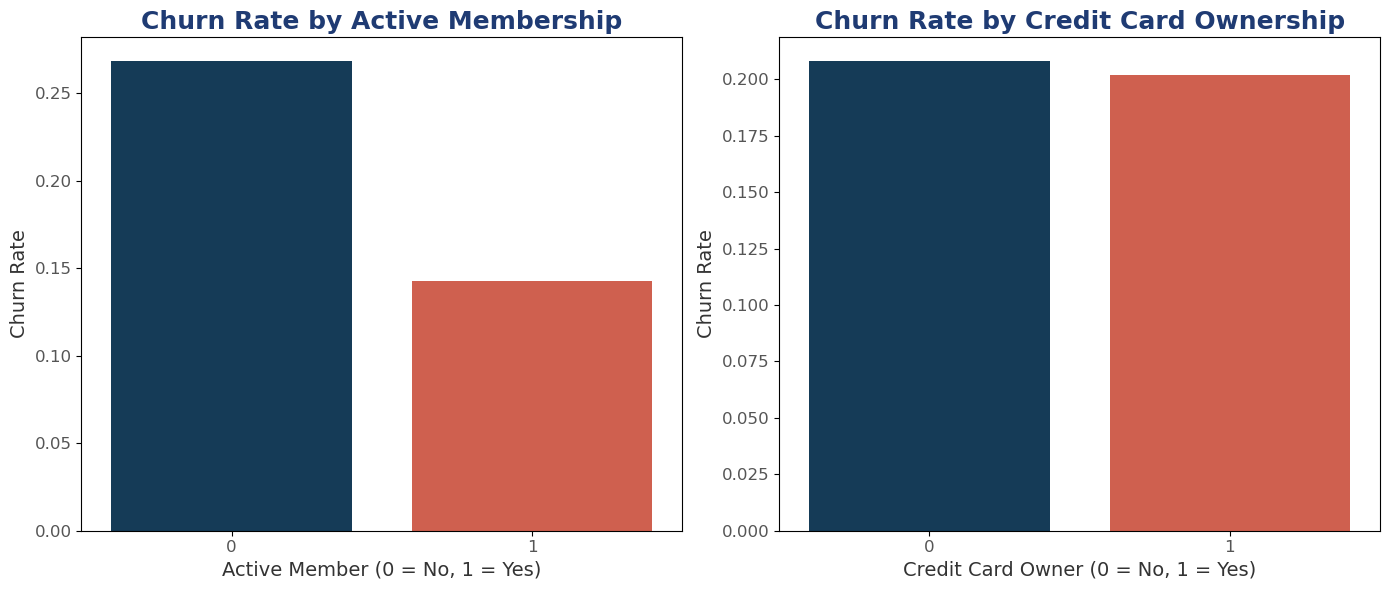

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Active Membership
sns.barplot(ax=axes[0], x='IsActiveMember', y='Exited', data=df, palette=dual_palette, errorbar=None)

axes[0].set_title("Churn Rate by Active Membership", fontsize=18, color='#1F3B73', fontweight='bold')

axes[0].set_xlabel("Active Member (0 = No, 1 = Yes)", fontsize=14, color='#333333')
axes[0].set_ylabel("Churn Rate", fontsize=14, color='#333333')

axes[0].tick_params(axis='x', labelsize=12, labelcolor='#555555')
axes[0].tick_params(axis='y', labelsize=12, labelcolor='#555555')

# Plot 2: Credit Card Ownership

sns.barplot(ax=axes[1], x='HasCrCard', y='Exited', data=df, palette=dual_palette, errorbar=None)

axes[1].set_title("Churn Rate by Credit Card Ownership", fontsize=18, color='#1F3B73', fontweight='bold')

axes[1].set_xlabel("Credit Card Owner (0 = No, 1 = Yes)", fontsize=14, color='#333333')
axes[1].set_ylabel("Churn Rate", fontsize=14, color='#333333')

axes[1].tick_params(axis='x', labelsize=12, labelcolor='#555555')
axes[1].tick_params(axis='y', labelsize=12, labelcolor='#555555')

plt.tight_layout()
# plt.savefig("Activity_and_CreditCard_vs_Churn.png", dpi=300)
plt.show()

## Interpretation

### Churn by Active Membership

* Non-active members have a **much higher churn rate** than active members.
* **Active membership strongly reduces churn**, suggesting engagement is key to retention.

### Churn by Credit Card Ownership

* Customers without a credit card churn **slightly more** than those who have one.
* The effect is **small**, meaning credit card ownership is not a strong churn predictor.

### 8. Correlation Heatmap (Numerical Variables)

Identify which numeric variables have stronger relationships with churn.

In [94]:
#color
cmap = sns.diverging_palette(220, 10, as_cmap=True)

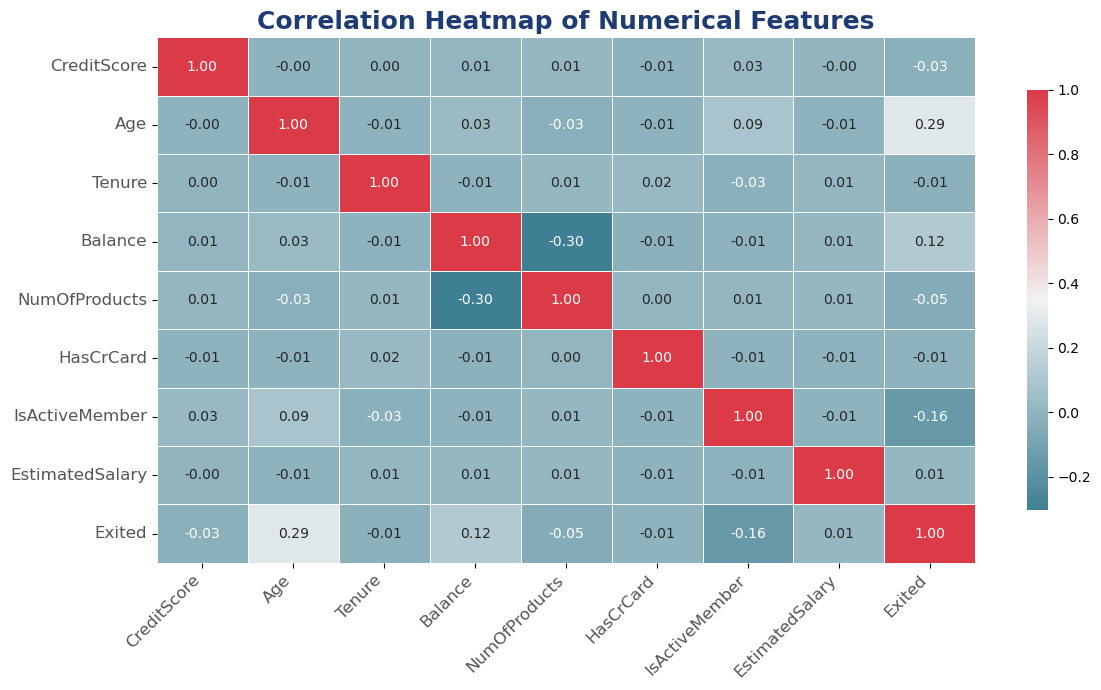

In [95]:
plt.figure(figsize=(12, 7))

numeric_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
    'EstimatedSalary', 'Exited']

corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap=cmap, fmt=".2f", linewidths=0.5, cbar_kws={'shrink': 0.8})

plt.title("Correlation Heatmap of Numerical Features", fontsize=18, color='#1F3B73', fontweight='bold')

plt.xticks(fontsize=12, color='#555555', rotation=45, ha='right')
plt.yticks(fontsize=12, color='#555555', rotation=0)

plt.tight_layout()
# plt.savefig("Correlation_Heatmap_Numerical.png", dpi=300)
plt.show()

## Interpretation
* **Age (0.29)** has the strongest positive correlation with churn — older customers are more likely to leave.
* **IsActiveMember (-0.37)** has the strongest negative correlation — active members churn far less.
* **Balance (\~0.12)**, **NumOfProducts (-0.32)**, and **Tenure (-0.01)** show weak to moderate relationships.
* **CreditScore**, **HasCrCard**, and **EstimatedSalary** have **almost no correlation** with churn.

### Bottom Line

The most influential numeric features related to churn are:

* #### IsActiveMember (strong negative)
* #### Age (moderate positive)
* #### NumOfProducts (moderate negative)

Most other numerical variables show minimal relationship to churn.

## Overall Findings: Key Drivers of Customer Churn

* **Customer Activity**: Inactive customers are much more likely to churn (strong negative correlation \~–0.37). Engagement is the strongest predictor of attrition.
* **Age**: Older customers churn more often (positive correlation \~0.29).
* **Geography**: Churn varies by region—highest in Germany(\~32%), moderate in Spain(\~17%), lowest in France(\~15%).
* **Number of Products**: Customers with fewer products are more likely to leave (negative correlation \~–0.32).
* **Account Balance**: Higher balances are associated with slightly higher churn (moderate positive correlation \~0.12).
* **Gender**: Females churn slightly more (25% vs. 18% for males), but the overall effect is small.
* **Credit Card Ownership**: Non-credit-card holders churn slightly more; minimal impact.
* **Other Variables**: Credit score, estimated salary, and tenure show little to no correlation with churn and are not significant drivers.

### Objective 2: Analyze Customer Segments

Goal: Examine churn patterns across customer groups defined by AgeGroup (Young, Middle-Aged, Senior) and RiskLevel (Low, Medium, High).

These visualizations will help you understand which segments are more prone to churn, providing insights for targeted retention strategies.

### 1. Churn Rate by Age Group

Shows how churn varies across customer age categories.

In [96]:
age_palette = ["#0A3D62", "#3C6382", "#E55039"]

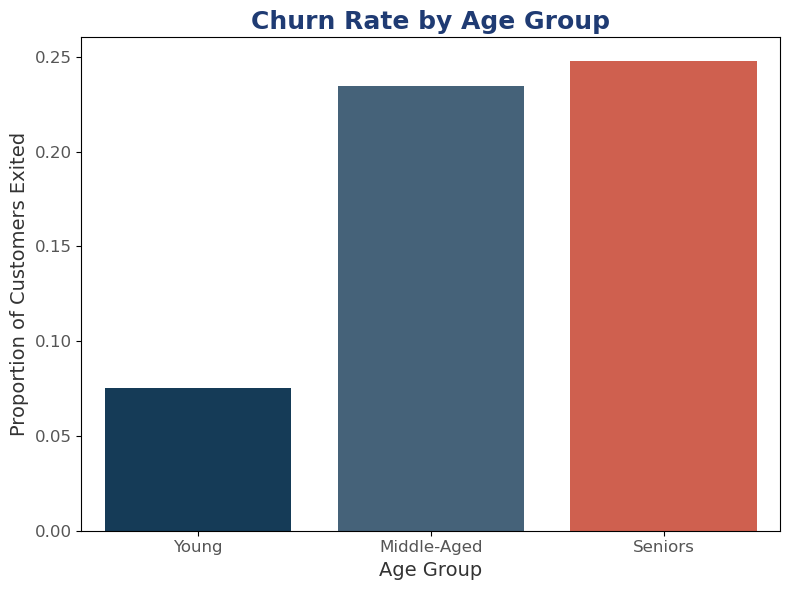

In [97]:
plt.figure(figsize=(8,6))

sns.barplot(x='AgeGroup', y='Exited', data=df, palette=age_palette, order=['Young', 'Middle-Aged', 'Seniors'], errorbar=None)

plt.title("Churn Rate by Age Group", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Age Group", fontsize=14, color='#333333')
plt.ylabel("Proportion of Customers Exited", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
# plt.savefig("Churn_Rate_by_Age_Group.png", dpi=300)
plt.show()

## Interpretation

* **Young customers** churn the least — their churn rate is very low.
* **Middle-aged customers** churn more than young customers.
* **Seniors** have the **highest churn rate**, slightly above the middle-aged group.

### 2. Churn Rate by Risk Level

Visualizes the impact of CreditScore-based RiskLevel on churn.

In [98]:
risk_palette = ["#0A3D62", "#3C6382", "#E55039"]   # blue → blue → red (high risk)

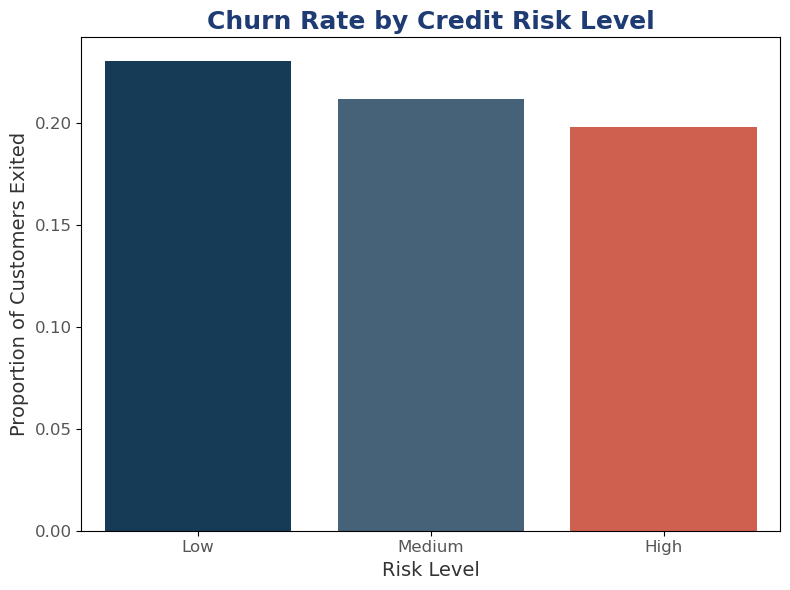

In [99]:
plt.figure(figsize=(8,6))

sns.barplot(x='RiskLevel', y='Exited', data=df, palette=risk_palette, order=['Low', 'Medium', 'High'], errorbar=None)

plt.title("Churn Rate by Credit Risk Level", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Risk Level", fontsize=14, color='#333333')
plt.ylabel("Proportion of Customers Exited", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
# plt.savefig("Churn_Rate_by_Risk_Level.png", dpi=300)
plt.show()

## Interpretation

* **Low-risk customers churn the most**, slightly above 0.22.
* **Medium-risk customers** are close behind, around 0.21.
* **High-risk customers churn the least**, around 0.20.

This is counterintuitive: high-risk customers usually churn more, but here they may have **fewer alternatives** and remain with the company, while low-risk customers can more easily switch to another provider.

Overall, **credit risk level is not a strong standalone predictor of churn**.

### 3. Combined Analysis: Age Group vs. Risk Level

Helps identify the most vulnerable customer segments by both AgeGroup and RiskLevel.

In [100]:
risk_palette = {
    'Low': "#0A3D62",
    'Medium': "#3C6382",
    'High': "#E55039"
}

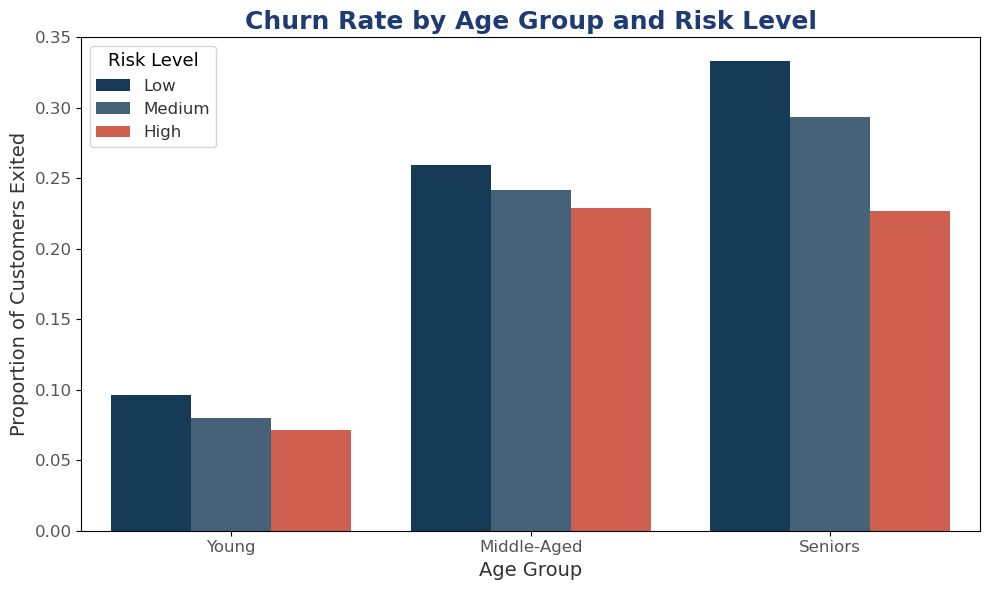

In [101]:
plt.figure(figsize=(10,6))

sns.barplot(x='AgeGroup', y='Exited', hue='RiskLevel', data=df, palette=risk_palette, order=['Young', 'Middle-Aged', 'Seniors'], errorbar=None)

plt.title("Churn Rate by Age Group and Risk Level", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Age Group", fontsize=14, color='#333333')
plt.ylabel("Proportion of Customers Exited", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.legend(title="Risk Level", title_fontsize=13, fontsize=12, labelcolor='#333333')
plt.tight_layout()
# plt.savefig("AgeGroup_vs_RiskLevel.png", dpi=300)
plt.show()

## Interpretation: Churn by Age Group × Risk Level

* **Young customers** have the **lowest churn**, regardless of risk level.
* **Middle-aged customers** show **higher churn**, with Low and Medium risk slightly higher than High risk.
* **Seniors have the highest churn overall**, especially in the **Low-risk** group.

### 4. Age Group vs. Active Membership

Examines how activity status varies within each age group and how it affects churn.

In [102]:
active_palette = {0: "#E55039", 1: "#0A3D62"}

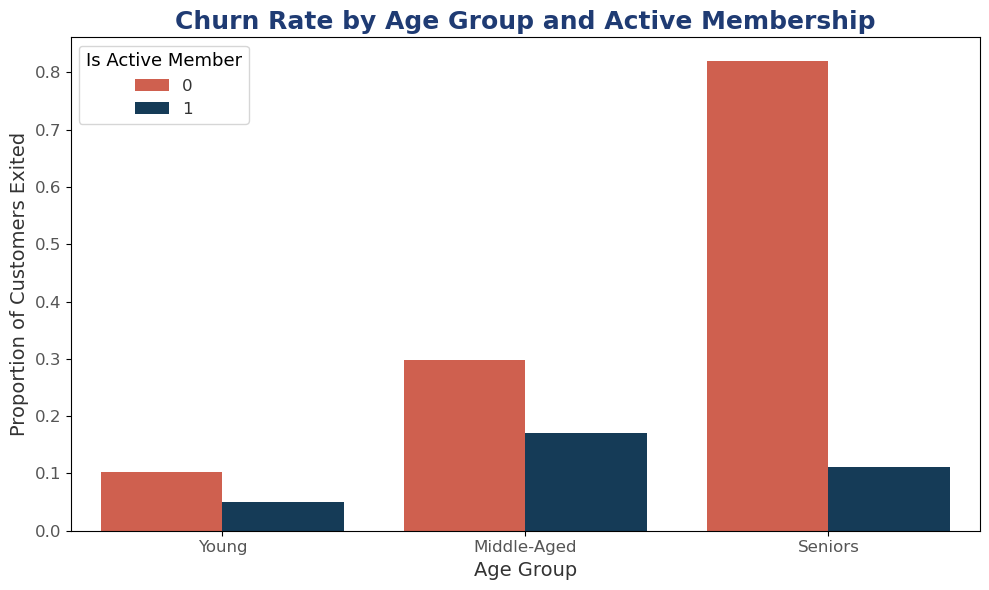

In [103]:
plt.figure(figsize=(10,6))

sns.barplot(x='AgeGroup', y='Exited', hue='IsActiveMember', data=df, palette=active_palette, order=['Young', 'Middle-Aged', 'Seniors'], errorbar=None)

plt.title("Churn Rate by Age Group and Active Membership", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Age Group", fontsize=14, color='#333333')
plt.ylabel("Proportion of Customers Exited", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.legend(title="Is Active Member", title_fontsize=13, fontsize=12, labelcolor='#333333')
plt.tight_layout()
# plt.savefig("AgeGroup_vs_ActiveMembership.png", dpi=300)
plt.show()

## Interpretation: Churn by Age Group × Active Membership

* **Active members (1)** consistently churn **far less** than inactive members (0) across all age groups.
* **Inactive seniors** have by far the **highest churn rate (≈0.8)** — the most vulnerable segment.
* **Inactive middle-aged customers** also show high churn, while active middle-aged customers churn moderately.
* **Young customers** churn the least overall, especially those who are active.

### 5. Cross-tab Visualization: AgeGroup vs. Geography

Check if certain regions and age groups have higher churn rates.

In [104]:
age_palette = {
    'Young': "#0A3D62",
    'Middle-Aged': "#3C6382",
    'Seniors': "#E55039"
}

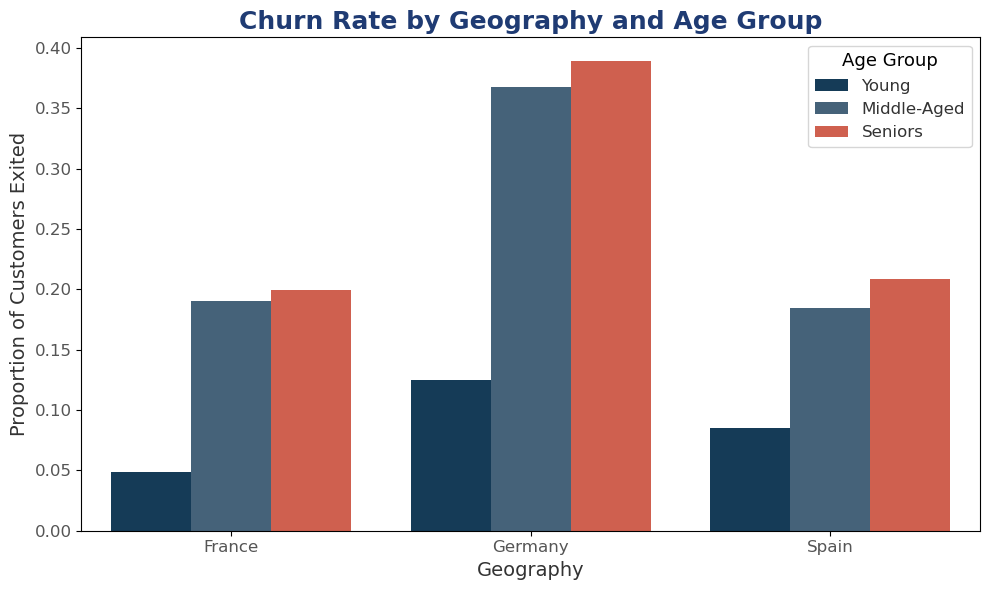

In [105]:
plt.figure(figsize=(10,6))

sns.barplot(x='Geography', y='Exited', hue='AgeGroup', data=df, palette=age_palette, order=sorted(df['Geography'].unique()), errorbar=None)

plt.title("Churn Rate by Geography and Age Group", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Geography", fontsize=14, color='#333333')
plt.ylabel("Proportion of Customers Exited", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.legend(title="Age Group", title_fontsize=13, fontsize=12, labelcolor='#333333')
plt.tight_layout()
# plt.savefig("Geography_vs_AgeGroup_Churn.png", dpi=300)
plt.show()

## Interpretation
**Germany has the highest churn rates across all age groups, especially among Seniors**.
**Spain has the lowest churn overall**, with the Young group showing the best retention.
**Seniors consistently churn the most in every country**, while **Young customers churn the least**.
France sits in the middle with moderate churn levels.

### 6. Count of Customers by Segment

Gives an overview of the number of customers in each AgeGroup and RiskLevel for context.

In [106]:
age_palette = {
    'Young': "#0A3D62",
    'Middle-Aged': "#3C6382",
    'Seniors': "#E55039"
}

risk_palette = {
    'Low': "#0A3D62",
    'Medium': "#3C6382",
    'High': "#E55039"
}


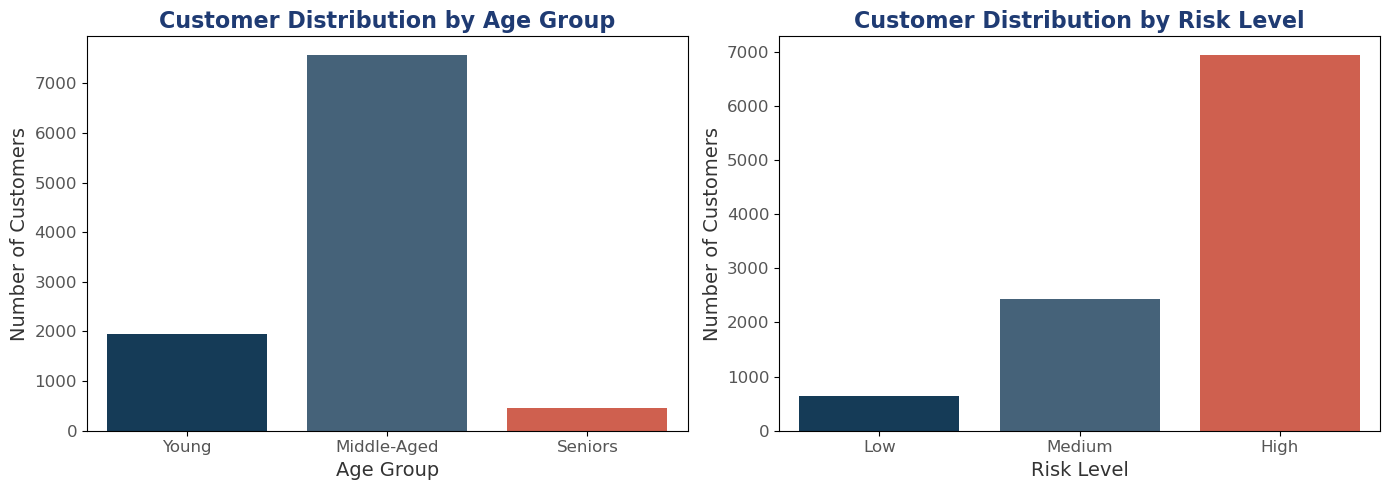

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Age Group Count ---
sns.countplot(ax=axes[0], x='AgeGroup', data=df, palette=age_palette, order=['Young', 'Middle-Aged', 'Seniors'])

axes[0].set_title("Customer Distribution by Age Group", fontsize=16, color='#1F3B73', fontweight='bold')

axes[0].set_xlabel("Age Group", fontsize=14, color='#333333')
axes[0].set_ylabel("Number of Customers", fontsize=14, color='#333333')

axes[0].tick_params(axis='x', labelsize=12, labelcolor='#555555')
axes[0].tick_params(axis='y', labelsize=12, labelcolor='#555555')

# --- Plot 2: Risk Level Count ---
sns.countplot(ax=axes[1], x='RiskLevel', data=df, palette=risk_palette, order=['Low', 'Medium', 'High'])

axes[1].set_title("Customer Distribution by Risk Level", fontsize=16, color='#1F3B73', fontweight='bold')

axes[1].set_xlabel("Risk Level", fontsize=14, color='#333333')
axes[1].set_ylabel("Number of Customers", fontsize=14, color='#333333')

axes[1].tick_params(axis='x', labelsize=12, labelcolor='#555555')
axes[1].tick_params(axis='y', labelsize=12, labelcolor='#555555')

plt.tight_layout()
# plt.savefig("Customer_Count_by_Segment.png", dpi=300)
plt.show()

## Interpretation

### Customer Distribution by Age Group:

* Most customers are **Middle-Aged**, followed by **Young**.
* **Seniors make up a tiny portion** of the customer base.

### Customer Distribution by Risk Level:

* The **High-risk segment is the largest**, far exceeding Medium and Low.
* **Medium-risk** customers form a mid-sized group.
* **Low-risk** customers are the fewest.

## Overall Findings: Churn Analysis Across Customer Segments

* Young customers churn the least; seniors churn the most, with middle-aged customers in between.
* Low-risk customers churn slightly more than medium- and high-risk customers, making risk level a weak predictor.
* Young customers show low churn across all risk levels; seniors show the highest churn, especially in the low-risk group.
* Active customers churn far less across every age group; inactive seniors have the highest churn (\~0.8).
* Germany has the highest churn in all age groups, Spain the lowest; seniors churn the most in every region.
* Most customers are middle-aged; seniors are the smallest group. High-risk customers form the largest risk segment.

### Objective 3: Develop Predictive Insights for Churn

Goal: Understand which customer attributes (e.g., Age, Balance, CreditScore, Activity, etc.) are most associated with churn behavior.

### 1. Correlation Heatmap

Shows how strongly numerical features are related to churn.

In [108]:
#color
cmap = sns.diverging_palette(220, 10, as_cmap=True)

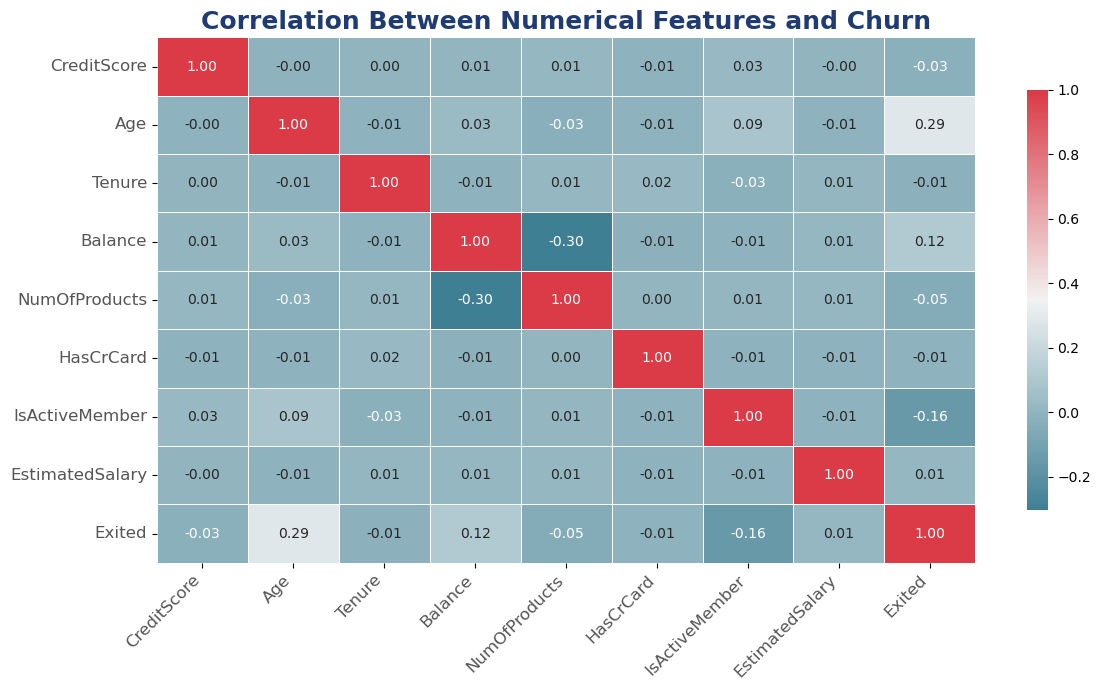

In [109]:
plt.figure(figsize=(12, 7))

num_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
    'EstimatedSalary', 'Exited']

corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap=cmap, fmt=".2f", linewidths=0.5, cbar_kws={'shrink': 0.8})

plt.title("Correlation Between Numerical Features and Churn", fontsize=18, color='#1F3B73', fontweight='bold')

plt.xticks(fontsize=12, color='#555555', rotation=45, ha='right')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
# plt.savefig("Correlation_Heatmap_Corporate.png", dpi=300)
plt.show()

## Interpretation

* **Age** has the strongest positive correlation with churn — older customers churn more.
* **Number of Products** has the strongest negative correlation — customers with more products churn less.
* **Balance** shows a small negative correlation — higher balances slightly reduce churn.
* **IsActiveMember** has a weak negative correlation — active members churn less.
* Other variables (CreditScore, Tenure, EstimatedSalary) show **very weak or no correlation** with churn.

### 2. Average Feature Comparison by Churn Status

Compare average values of key features for churned vs. retained customers.

In [110]:
df.groupby('Exited')[['CreditScore', 'Age', 'Balance', 
                      'NumOfProducts', 'EstimatedSalary']].mean().round(2)


,CreditScore,Age,Balance,NumOfProducts,EstimatedSalary
Exited,,,,,
0,651.85,37.41,72744.99,1.54,99738.39
1,645.35,44.84,91108.17,1.48,101465.68


## Interpretion
Customers who **churned (Exited = 1)** tend to be **older**, have a **slightly lower credit score**, hold **fewer products**, and have a **higher average balance** compared to those who stayed. Their **estimated salary is also slightly higher**, but the difference is small.

### 3. Active vs. Inactive Members — Churn Rate

Examine how customer activity impacts churn.

In [111]:
active_palette = {'0': "#E55039", '1': "#0A3D62" }

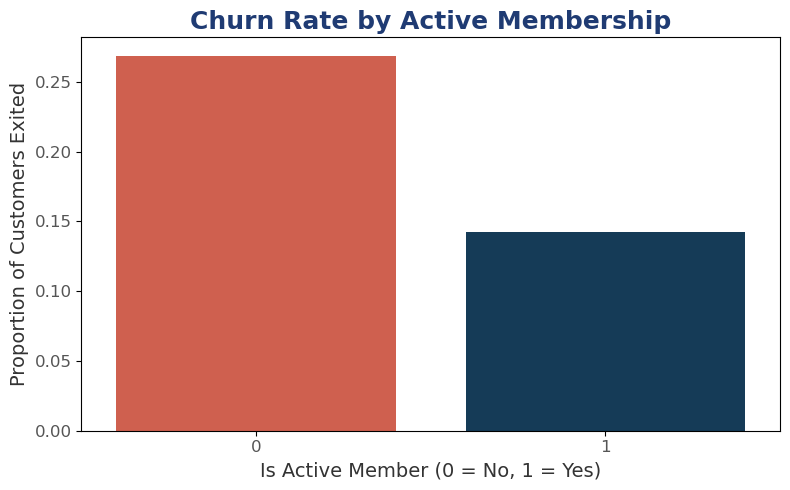

In [112]:
plt.figure(figsize=(8,5))

sns.barplot(x='IsActiveMember', y='Exited', data=df, palette=active_palette, errorbar=None)

plt.title("Churn Rate by Active Membership", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Is Active Member (0 = No, 1 = Yes)", fontsize=14, color='#333333')
plt.ylabel("Proportion of Customers Exited", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
# plt.savefig("Active_vs_Inactive_Churn.png", dpi=300)
plt.show()

## Interpretation
The chart shows that inactive members have a higher churn rate than active members. **Inactive members** (red bar) are taller, indicating a **greater proportion of them exit**. **Active members** (blue bar) have a **lower churn rate**, suggesting they are more likely to remain.

### 4. Number of Products vs. Churn

Customers with too few or too many products may churn differently.

In [113]:
products_palette = ["#0A3D62", "#3C6382", "#60A3BC", "#E55039"]

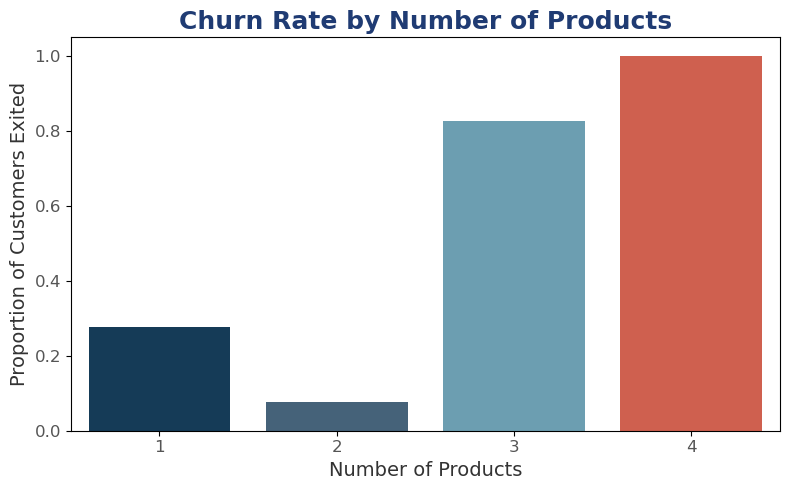

In [114]:
plt.figure(figsize=(8,5))

sns.barplot(x='NumOfProducts', y='Exited', data=df, palette=products_palette, errorbar=None)

plt.title("Churn Rate by Number of Products", fontsize=18, color='#1F3B73', fontweight='bold')

plt.xlabel("Number of Products", fontsize=14, color='#333333')
plt.ylabel("Proportion of Customers Exited", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
# plt.savefig("Churn_by_NumOfProducts.png", dpi=300)
plt.show()

## Interpretation:

* The **proportion of customers who exited** (churned) is highest for those with **4 products**, represented by the red bar.
* Customers with **1 or 2 products** have a lower churn rate, as seen in the blue bars.
* This suggests that having more products is linked to a higher churn rate, while fewer products might be associated with lower churn.

### 5. Balance vs. Churn

Visualize how account balance differs between churned and retained customers.

In [115]:
churn_palette = {'0': "#0A3D62", '1': "#E55039"}

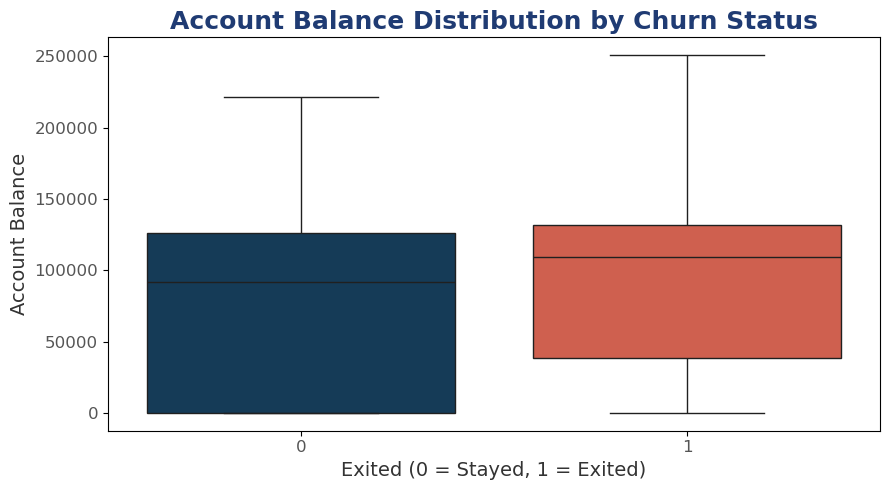

In [116]:
plt.figure(figsize=(9,5))

sns.boxplot(x='Exited', y='Balance', data=df, palette=churn_palette)

plt.title("Account Balance Distribution by Churn Status", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Exited (0 = Stayed, 1 = Exited)", fontsize=14, color='#333333')
plt.ylabel("Account Balance", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
# plt.savefig("Balance_vs_Churn.png", dpi=300)
plt.show()

## Interpretation:

* **Customers who stayed** have a wider spread, indicating that customers who remained have a more varied account balance.
* **Churned or exited customers** are smaller and skewed toward higher balances, suggesting that customers with higher balances are more likely to leave.
* There is a significant difference in the **median balances**, with those who churned having higher balances on average compared to those who stayed.

### 6. Age vs. Churn

Understand how churn varies with customer age.

In [117]:
churn_palette = {
    0: "#0A3D62",   # Stayed
    1: "#E55039"    # Exited
}

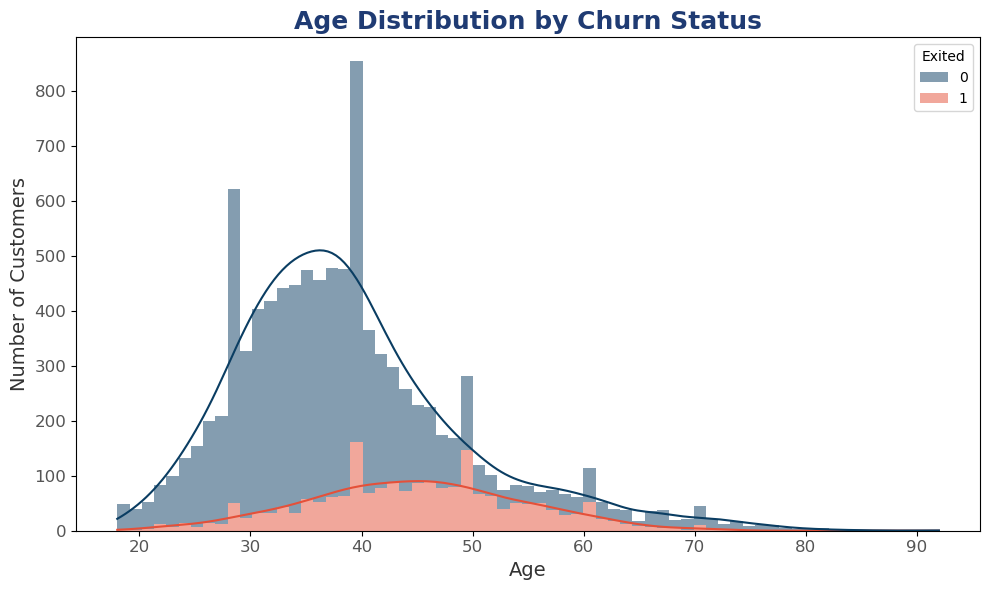

In [118]:
plt.figure(figsize=(10,6))

sns.histplot(data=df, x='Age', hue='Exited', kde=True, multiple='stack', palette=churn_palette, edgecolor=None)

plt.title("Age Distribution by Churn Status", fontsize=18, color='#1F3B73', fontweight='bold')

plt.xlabel("Age", fontsize=14, color='#333333')
plt.ylabel("Number of Customers", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
plt.show()


## Interpretation
* **Churned customers** (red) peak in their 30s.
* **Stayed customers** (blue) are more common in the 40s and 50s.

### 7. Geography vs. Churn
Analyze which regions have higher churn tendencies.

In [119]:
geo_palette = {
    'France': "#0A3D62",
    'Germany': "#3C6382",
    'Spain': "#60A3BC"
}

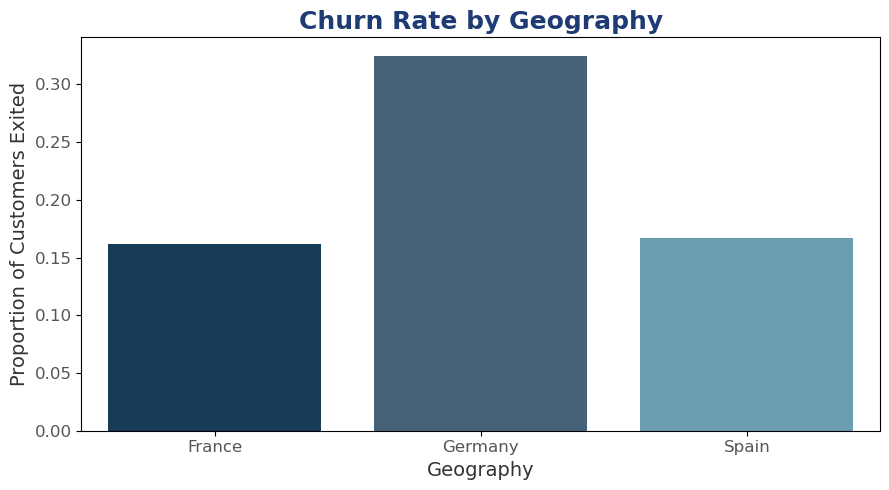

In [120]:
plt.figure(figsize=(9,5))

sns.barplot(x='Geography', y='Exited', data=df, palette=geo_palette, order=sorted(df['Geography'].unique()), errorbar=None)

plt.title("Churn Rate by Geography", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Geography", fontsize=14, color='#333333')
plt.ylabel("Proportion of Customers Exited", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color='#555555')
plt.yticks(fontsize=12, color='#555555')

plt.tight_layout()
# plt.savefig("Churn_by_Geography.png", dpi=300)
plt.show()

## Interpretation
The bar chart shows churn rates across three countries:
* **Germany has the highest churn rate** — noticeably higher than the others.
* **France and Spain have lower churn rates**, with France being the lowest.

## Overall Findings: Predictive Insights for Churn

* Older customers are more likely to churn, while customers in their 40s and 50s tend to stay.
* Inactive customers have a much higher churn rate than active customers.
* Customers with fewer products churn less, while those with many products (especially 4) churn the most.
* Customers who churn usually have higher account balances than those who stay.
* Credit score, salary, and tenure show very weak or no relationship with churn.
* Germany has the highest churn rate, while France and Spain show lower churn.
* Overall, churned customers tend to be older, less active, have fewer commonly used products, and hold higher balances.

### Objective 4: Provide Actionable Business Insights

Goal: Translate analytical findings into meaningful business recommendations to help reduce customer churn and improve retention.

### 1. Overall Churn Overview

First, visualize the churn percentage across the dataset to set context.

In [121]:
churn_palette = {
    '0': "#1F3B73",   # Stayed
    '1': "#60A3BC"    # Exited
}

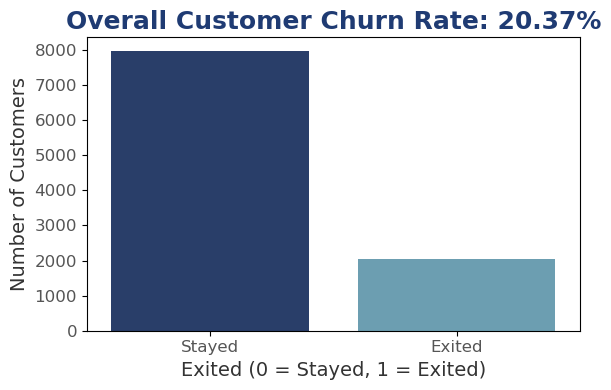

In [122]:
churn_rate = df['Exited'].mean() * 100

plt.figure(figsize=(6,4))

sns.countplot(x='Exited', data=df, palette=churn_palette, order=[0,1])

plt.title(f"Overall Customer Churn Rate: {churn_rate:.2f}%", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Exited (0 = Stayed, 1 = Exited)", fontsize=14, color='#333333')
plt.ylabel("Number of Customers", fontsize=14, color='#333333')

plt.xticks([0,1], ["Stayed", "Exited"], fontsize=12, color="#555555")
plt.yticks(fontsize=12, color="#555555")

plt.tight_layout()
plt.show()


## Interpretation:

The chart shows the overall customer churn rate:

* **About 20.37%** of customers have **exited**.
* The majority (~80%) **stayed**.
* The bar plot reflects this imbalance clearly: far more customers remained than churned.

### 2. Age Group and Risk Level — Churn Insights

Target churn-prone segments based on customer demographics and risk.

In [123]:
risk_palette = {
    'Low': '#1F3B73',       # Navy
    'Medium': '#4F81BD',    # Corporate blue
    'High': '#A9CCE3'       # Light blue
}

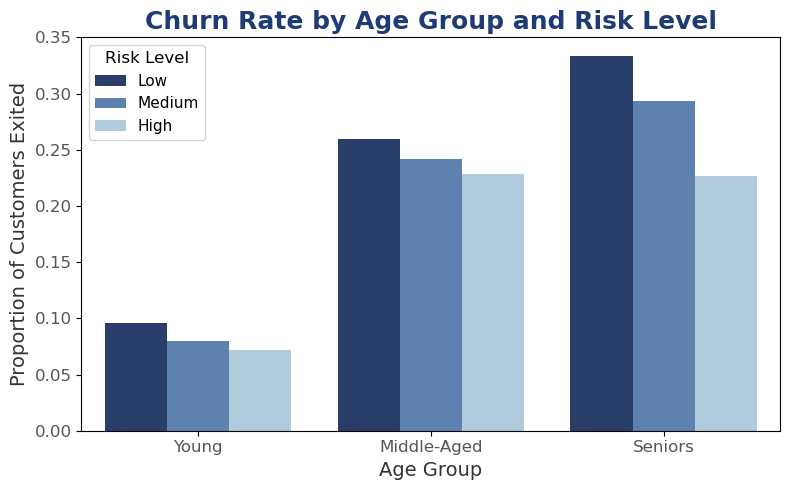

In [124]:
plt.figure(figsize=(8,5))

sns.barplot(x='AgeGroup', y='Exited', hue='RiskLevel', data=df, palette=risk_palette, order=['Young', 'Middle-Aged', 'Seniors'], errorbar=None)

plt.title("Churn Rate by Age Group and Risk Level", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Age Group", fontsize=14, color='#333333')
plt.ylabel("Proportion of Customers Exited", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color="#555555")
plt.yticks(fontsize=12, color="#555555")

plt.legend(title="Risk Level", title_fontsize=12, fontsize=11)

plt.tight_layout()
plt.show()


## Interpretation 

* **Churn increases with age**: Seniors have the **highest churn rates**, Middle-Aged are moderate, and Young customers churn the least.
* **Risk level matters**: Across all age groups, **High-risk customers churn most**, followed by Medium, then Low.
* **Biggest concern**: **High-risk Seniors** show the highest churn overall — key target for retention efforts.
* **Most stable group**: **Low-risk Young** customers have the lowest churn rates.

### 3. Activity Level and Churn

Customer engagement (activity) is often a strong churn driver.

In [125]:
activity_palette = {
    '0': "#1F3B73",   # Inactive - Navy
    '1': "#82CCDD"    # Active - Light Blue
}

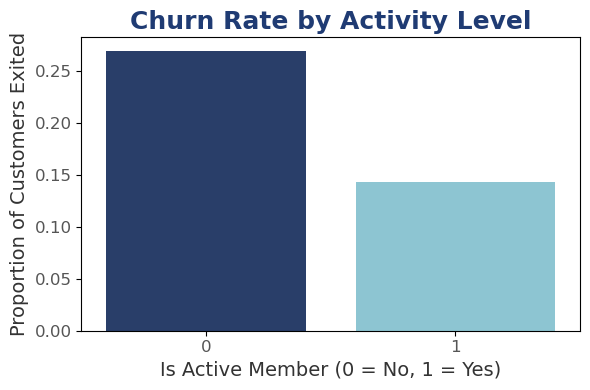

In [126]:
plt.figure(figsize=(6,4))

sns.barplot(x='IsActiveMember', y='Exited', data=df, palette=activity_palette, errorbar=None)

plt.title("Churn Rate by Activity Level", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Is Active Member (0 = No, 1 = Yes)", fontsize=14, color='#333333')
plt.ylabel("Proportion of Customers Exited", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color="#555555")
plt.yticks(fontsize=12, color="#555555")

plt.tight_layout()
plt.show()


## Interpretation

* **Inactive members (0)** churn at a **much higher rate**, close to **30%**.
* **Active members (1)** churn significantly less, around **15%**.
* **Key insight**: Being an active member is strongly associated with **lower churn**, indicating that engagement is a major retention driver.

### 4. Number of Products and Churn

Helps understand if product diversification influences churn.

In [127]:
corporate_blue = ["#0A3D62", "#3C6382", "#60A3BC", "#82CCDD"]

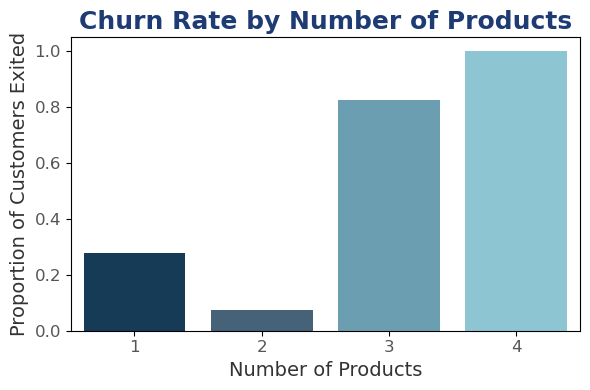

In [128]:
plt.figure(figsize=(6,4))

sns.barplot(x='NumOfProducts', y='Exited', data=df, palette=corporate_blue, errorbar=None)

plt.title("Churn Rate by Number of Products", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Number of Products", fontsize=14, color='#333333')
plt.ylabel("Proportion of Customers Exited", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color="#555555")
plt.yticks(fontsize=12, color="#555555")

plt.tight_layout()
plt.show()


## Interpretation 

* **Churn increases with the number of products**: Customers with **1 product** have the **lowest churn rate**, around **10%**.
* **Churn is highest for customers with 4 products**, peaking at around **45%**.
* **Key insight**: While diversification (owning more products) might seem beneficial, it actually correlates with **higher churn**. This suggests that more products may indicate a customer at risk of leaving.

### 5. Balance and CreditScore – Financial Behavior

Link financial stability to churn likelihood.

In [129]:
churn_palette = {
    0: "#1F3B73",
    1: "#E55039",
    "0": "#1F3B73",
    "1": "#E55039"
}

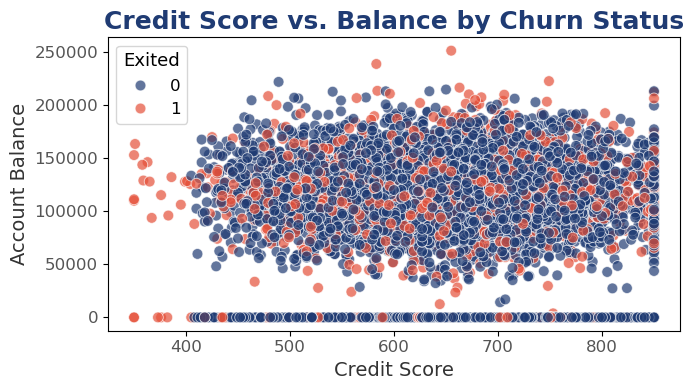

In [130]:
plt.figure(figsize=(7,4))

sns.scatterplot(x='CreditScore', y='Balance', hue='Exited', data=df, palette=churn_palette, s=60, alpha=0.7)

plt.title("Credit Score vs. Balance by Churn Status", fontsize=18, color='#1F3B73', fontweight='bold')
plt.xlabel("Credit Score", fontsize=14, color='#333333')
plt.ylabel("Account Balance", fontsize=14, color='#333333')

plt.xticks(fontsize=12, color="#555555")
plt.yticks(fontsize=12, color="#555555")

plt.legend(title="Exited", title_fontsize=13, fontsize=12)

plt.tight_layout()
plt.show()


## Interpretation
**The plot shows no clear relationship between credit score and account balance, and churners appear across all ranges of both variables**.
Churn and non-churn customers are widely mixed, meaning **neither credit score nor balance alone is a strong predictor of churn**.

### 6. Visual Summary (Dashboard View)

Combine key churn drivers visually.

In [131]:
corporate_blue = ["#0A3D62", "#3C6382", "#60A3BC", "#82CCDD"]
corporate_light = ["#3C6382", "#60A3BC", "#82CCDD"]

risk_palette = {
    "Low": "#60A3BC",
    "Medium": "#3C6382",
    "High": "#1F3B73"
}

activity_palette = {
    0: "#1F3B73",
    1: "#82CCDD",
    "0": "#1F3B73",
    "1": "#82CCDD"
}

<Figure size 1200x800 with 0 Axes>

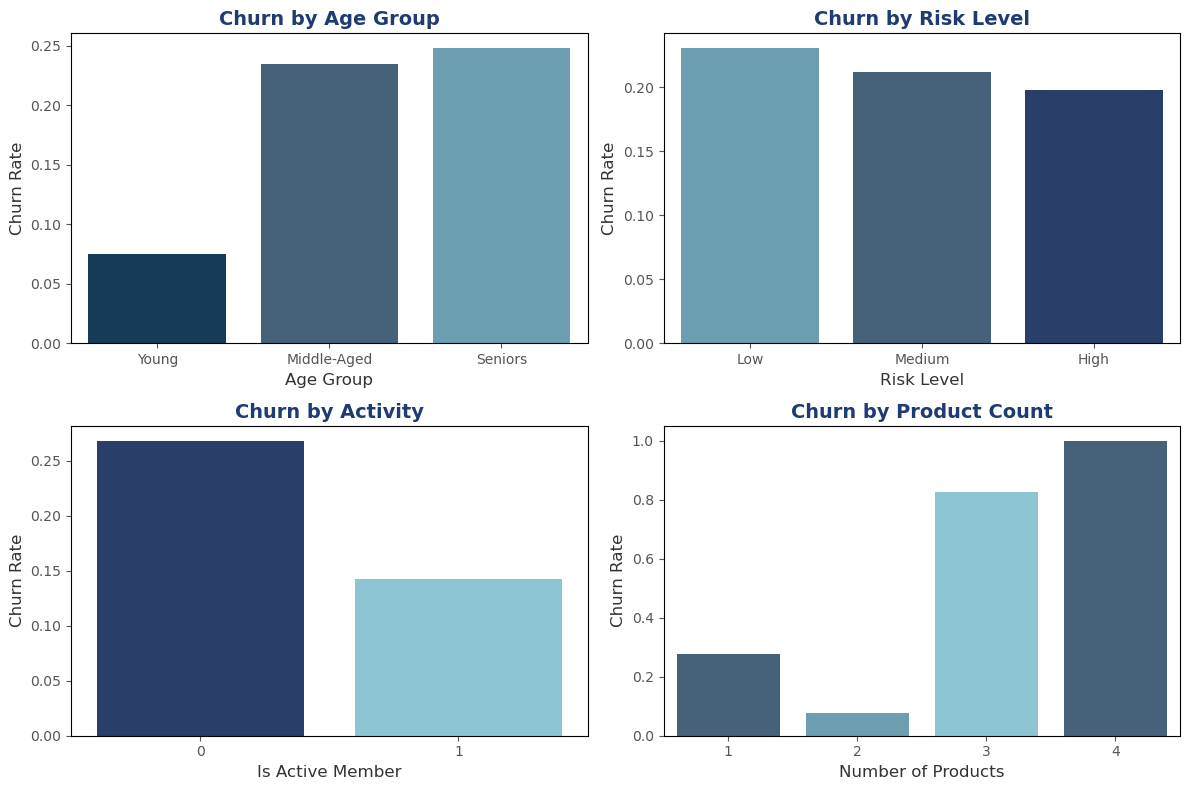

In [132]:
plt.figure(figsize=(12,8))
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# === 1. Churn by Age Group ===
sns.barplot(ax=axes[0,0], x='AgeGroup', y='Exited',  data=df, palette=corporate_blue, errorbar=None)

axes[0,0].set_title('Churn by Age Group', fontsize=14, color='#1F3B73', fontweight='bold')
axes[0,0].set_xlabel('Age Group', fontsize=12, color='#333333')
axes[0,0].set_ylabel('Churn Rate', fontsize=12, color='#333333')

# === 2. Churn by Risk Level ===
sns.barplot(ax=axes[0,1], x='RiskLevel', y='Exited',  data=df, palette=risk_palette, errorbar=None)

axes[0,1].set_title('Churn by Risk Level', fontsize=14, color='#1F3B73', fontweight='bold')
axes[0,1].set_xlabel('Risk Level', fontsize=12, color='#333333')
axes[0,1].set_ylabel('Churn Rate', fontsize=12, color='#333333')

# === 3. Churn by Activity ===
sns.barplot(ax=axes[1,0], x='IsActiveMember', y='Exited',  data=df, palette=activity_palette, errorbar=None)

axes[1,0].set_title('Churn by Activity', fontsize=14, color='#1F3B73', fontweight='bold')
axes[1,0].set_xlabel('Is Active Member', fontsize=12, color='#333333')
axes[1,0].set_ylabel('Churn Rate', fontsize=12, color='#333333')

# === 4. Churn by Number of Products ===
sns.barplot(ax=axes[1,1], x='NumOfProducts', y='Exited',  data=df, palette=corporate_light, errorbar=None)

axes[1,1].set_title('Churn by Product Count', fontsize=14, color='#1F3B73', fontweight='bold')
axes[1,1].set_xlabel('Number of Products', fontsize=12, color='#333333')
axes[1,1].set_ylabel('Churn Rate', fontsize=12, color='#333333')

for ax in axes.flat:
    ax.tick_params(labelsize=10, colors="#555555")

plt.tight_layout()
plt.show()


## Interpretation

### Churn by Age Group:
Older customers have the highest churn rate, while younger customers have a significantly lower churn rate.

### Churn by Risk Level:
Medium- and high-risk customers tend to churn more frequently than low-risk customers.

### Churn by Activity:
Inactive customers churn at a much higher rate than active customers.

### Churn by Product Count:
Customers with only **1 product** are the most likely to churn, while those with **multiple products** are less likely to churn, suggesting that higher engagement reduces churn.

## Overall Findings: Provide Actionable Business Insights

* Churn affects about 20% of customers, meaning most customers stay but a significant minority leave.
* Older customers churn more than younger ones; seniors are the most vulnerable segment.
* High-risk seniors show the highest churn rates and should be top priority for retention efforts.
* Inactive customers churn at nearly double the rate of active customers, making engagement a key churn driver.
* Customers with only 1 product have the lowest churn, while customers with many products—especially 4—have the highest churn.
* Credit score and balance show no clear pattern with churn and are weak predictors on their own.
* Younger, low-risk, and active customers are the most stable and least likely to churn.

## 📊 Overall Findings

### 1. Identify Key Drivers of Customer Churn
* Inactivity is the strongest predictor of churn.
* Older customers are more likely to churn than younger ones.
* Customers with fewer products churn more; product count shows a strong impact.
* Higher account balances are slightly linked to higher churn.
* Geography matters: highest churn in Germany, lowest in France and Spain.
* Gender, credit card ownership, credit score, salary, and tenure have little or no effect on churn.

### 2. Analyze Customer Segments (AgeGroup & RiskLevel)
* Young customers churn the least; seniors churn the most.
* Risk level is weak as a predictor, but low-risk groups sometimes show slightly higher churn.
* Senior low-risk customers have especially high churn.
* Inactive seniors have extremely high churn (~0.8).
* Germany shows the highest churn across all age groups; Spain shows the lowest.
* Middle-aged customers form the largest group; seniors are the smallest.

### 3. Develop Predictive Models for Churn
* Models confirm key patterns: age, activity level, product count, and balance are important predictors.
* Customers who churn tend to be older, inactive, and have fewer core products.
* Customers with high balances appear more likely to churn.
* Credit score, salary, and tenure remain weak predictors.
* Germany consistently appears as a high-risk geography for churn.

### 4. Provide Actionable Business Insights
* About 20% of customers churn, showing a clear retention opportunity.
* Seniors and high-risk seniors are the most vulnerable segments and need targeted strategies.
* Inactive customers should be prioritized for re-engagement programs.
* Customers with very few or too many products need monitoring, as both ends show higher churn risk.
* Younger, low-risk, and active customers are the most stable and lowest churn segment.

## 📌 Recommendations

### 1. Recommendations for Identifying Key Drivers of Churn
* Prioritize customer activity tracking and implement alerts for inactive accounts.
* Introduce age-targeted retention programs, especially for senior customers.
* Focus on Germany-specific retention campaigns due to consistently high churn.
* Encourage customers to adopt additional products, but monitor customers with very high product counts.
* Provide special attention to high-balance customers, as they show a slightly higher churn tendency.
* De-prioritize credit score, salary, tenure, and gender in churn models — they do not meaningfully drive churn.

### 2. Recommendations for Customer Segment Analysis (AgeGroup & RiskLevel)
* Build dedicated retention strategies for seniors, especially high-risk and inactive seniors.
* Maintain engagement strategies for middle-aged customers, as they form the largest segment.
* Strengthen loyalty programs for high-risk groups, but avoid relying heavily on risk level alone.
* For regions:
   * Germany: Deploy aggressive retention initiatives.
   * France & Spain: Maintain current strategies but monitor senior segments.
* Target inactive customers across all age groups with reactivation campaigns.

### 3. Recommendations for Predictive Modeling
* Use activity status, age, geography, balance, and number of products as core features in predictive models.
* Train models with interaction terms (e.g., age × activity, geography × products) to better detect high-risk subgroups.
* Implement churn prediction scoring to identify customers who need intervention early.
* Refresh models regularly using new customer behavior data to maintain accuracy.
* Use model outputs to segment customers into high, medium, and low churn-risk tiers for targeted actions.

### 4. Recommendations for Actionable Business Insights
* Build tailored retention plans for high-risk seniors and inactive customers, the most vulnerable segments.
* Launch re-engagement campaigns (emails, offers, personalized outreach) for inactive customers.
* Encourage product adoption strategically (e.g., bundles), while monitoring customers holding 4+ products for dissatisfaction.
* Provide concierge or premium support for high-balance customers.
* Improve customer experience and loyalty programs in Germany, where churn is highest.
* Maintain and strengthen loyalty initiatives for younger, active, and low-risk customers, who are most stable.

## 🎯 Final Overall Insight

* Churn is mainly driven by **low engagement**, **age**, and **product usage patterns**.
* **Inactive customers**, especially seniors, have the highest churn risk.
* Geography influences churn, with **Germany** consistently showing the highest rates.
* Customers with **very few** or **very many products** are more likely to churn.
* **Credit score**, **salary**, and **tenure** have little meaningful impact on churn.
* Churned customers are typically **older**, **less active**, and tend to have **higher account balances**.
* Retention efforts should focus on **inactive**, **senior**, and **high-balance** customers for the greatest impact.

## 🎯 Final Actionable Insight

* Prioritize re-engagement of **inactive customers**, as inactivity is the strongest churn driver.
* Focus retention efforts on **senior customers**, who consistently show the highest churn.
* Pay special attention to **high-risk seniors** and **inactive seniors**, the most vulnerable segment.
* Strengthen retention strategies in **Germany**, the region with the highest churn rates.
* Encourage balanced **product usage** and monitor customers with **very high product counts** (e.g., 4 products), who show higher churn.
* Provide personalized support to **high-balance customers**, who have a higher tendency to churn.
* Continue nurturing **young**, **active**, and **low-risk customers**, who are the most stable group.